# 0. Instalar pacotes e importar bibliotecas

In [28]:
# Dependências
import sys
#!{sys.executable} -m pip install --disable-pip-version-check -r ../requirements.txt -q
print('Bibliotecas instaladas')

Bibliotecas instaladas


In [29]:
# Dependências
from pathlib import Path
PROJECT_ROOT = Path().resolve().parent
sys.path.insert(0, str(PROJECT_ROOT))

# Diretórios
from configs.paths import *
from configs.function_basic import *
from configs.function_others import *

import numpy             as np
import matplotlib.pyplot as plt
import matplotlib        as mpl
import pandas            as pd
import seaborn           as sns
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from category_encoders import TargetEncoder
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.model_selection import train_test_split, GridSearchCV, RandomizedSearchCV, cross_val_score, ShuffleSplit
from xgboost import XGBClassifier
import lightgbm as lgb
from sklearn.ensemble import RandomForestClassifier, AdaBoostClassifier, GradientBoostingClassifier, ExtraTreesClassifier, \
HistGradientBoostingClassifier,StackingClassifier
from sklearn.tree import DecisionTreeClassifier
from catboost import CatBoostClassifier
from sklearn.metrics import confusion_matrix, classification_report, roc_curve, roc_auc_score, f1_score, make_scorer, accuracy_score, precision_score, recall_score, auc, precision_recall_curve, average_precision_score
import optuna
import pickle
from sklearn.ensemble import VotingClassifier, StackingClassifier
from sklearn.model_selection import StratifiedKFold
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis, QuadraticDiscriminantAnalysis
from sklearn.gaussian_process import GaussianProcessClassifier
from sklearn.linear_model import LogisticRegression, RidgeClassifier
from sklearn.naive_bayes import GaussianNB, BernoulliNB

# 1. Funções auxiliares

In [30]:
# Métricas do modelo

def calculate_metrics(nm_modelo, model, X_train, y_train, X_test, y_test):
    # Fazendo predições
    y_train_pred = model.predict(X_train)
    y_test_pred = model.predict(X_test)

    # Calculando as métricas para o conjunto de treino
    accuracy_train = accuracy_score(y_train, y_train_pred)
    precision_train = precision_score(y_train, y_train_pred)
    recall_train = recall_score(y_train, y_train_pred)
    auc_roc_train = roc_auc_score(y_train, model.predict_proba(X_train)[:, 1])

    # Calculando o Índice Gini e Estatística KS para o conjunto de treino
    probabilities_train = model.predict_proba(X_train)[:, 1]
    df_train = pd.DataFrame({'true_labels': y_train, 'predicted_probs': probabilities_train})
    df_train = df_train.sort_values(by='predicted_probs', ascending=False)
    df_train['cumulative_true'] = df_train['true_labels'].cumsum() / df_train['true_labels'].sum()
    df_train['cumulative_false'] = (1 - df_train['true_labels']).cumsum() / (1 - df_train['true_labels']).sum()
    ks_statistic_train = max(abs(df_train['cumulative_true'] - df_train['cumulative_false']))
    gini_index_train = 2 * auc_roc_train - 1

    # Calculando as métricas para o conjunto de teste
    accuracy_test = accuracy_score(y_test, y_test_pred)
    precision_test = precision_score(y_test, y_test_pred)
    recall_test = recall_score(y_test, y_test_pred)
    auc_roc_test = roc_auc_score(y_test, model.predict_proba(X_test)[:, 1])

    # Calculando o Índice Gini e Estatística KS para o conjunto de teste
    probabilities_test = model.predict_proba(X_test)[:, 1]
    df_test = pd.DataFrame({'true_labels': y_test, 'predicted_probs': probabilities_test})
    df_test = df_test.sort_values(by='predicted_probs', ascending=False)
    df_test['cumulative_true'] = df_test['true_labels'].cumsum() / df_test['true_labels'].sum()
    df_test['cumulative_false'] = (1 - df_test['true_labels']).cumsum() / (1 - df_test['true_labels']).sum()
    ks_statistic_test = max(abs(df_test['cumulative_true'] - df_test['cumulative_false']))
    gini_index_test = 2 * auc_roc_test - 1

    # Criando o DataFrame com as métricas calculadas
    metrics_df = pd.DataFrame({
        'Algoritmo': [nm_modelo, nm_modelo],
        'Conjunto': ['Treino', 'Teste'],
        'Acuracia': [accuracy_train, accuracy_test],
        'Precisao': [precision_train, precision_test],
        'Recall': [recall_train, recall_test],
        'AUC_ROC': [auc_roc_train, auc_roc_test],
        'GINI': [gini_index_train, gini_index_test],
        'KS': [ks_statistic_train, ks_statistic_test]
    })
    return metrics_df

def calculate_metrics_train(nm_modelo, X_train, y_train):
    # Fazendo predições
    y_train_prob = X_train.SCORE_FRAUDE
    y_train_pred = (y_train_prob > 0.5).astype(int)

    # Calculando as métricas para o conjunto de treino
    accuracy_train = accuracy_score(y_train, y_train_pred)
    precision_train = precision_score(y_train, y_train_pred)
    recall_train = recall_score(y_train, y_train_pred)
    auc_roc_train = roc_auc_score(y_train, y_train_prob)

    # Calculando o Índice Gini e Estatística KS para o conjunto de treino
    probabilities_train = y_train_prob
    df_train = pd.DataFrame({'true_labels': y_train, 'predicted_probs': probabilities_train})
    df_train = df_train.sort_values(by='predicted_probs', ascending=False)
    df_train['cumulative_true'] = df_train['true_labels'].cumsum() / df_train['true_labels'].sum()
    df_train['cumulative_false'] = (1 - df_train['true_labels']).cumsum() / (1 - df_train['true_labels']).sum()
    ks_statistic_train = max(abs(df_train['cumulative_true'] - df_train['cumulative_false']))
    gini_index_train = 2 * auc_roc_train - 1

    # Criando o DataFrame com as métricas calculadas
    metrics_df = pd.DataFrame({
        'Algoritmo': [nm_modelo],
        'Conjunto': ['Treino'],
        'Acuracia': [accuracy_train],
        'Precisao': [precision_train],
        'Recall': [recall_train],
        'AUC_ROC': [auc_roc_train],
        'GINI': [gini_index_train],
        'KS': [ks_statistic_train]
    })
    return metrics_df

def plot_metrics(model, X_train, y_train, X_test, y_test, features):
    plt.figure(figsize=(15, 18))

    # Gráfico de Barras para Taxa do Evento e Importância das Variáveis
    plt.subplot(4, 2, 1)
    event_rate = y_train.mean()
    non_event_rate = 1 - event_rate
    plt.barh(['Não Evento', 'Evento'], [non_event_rate, event_rate], color=['lightsteelblue', 'skyblue'])
    plt.xlabel('Taxa')
    plt.title('Taxa do Evento')

    plt.subplot(4, 2, 2)
    importances = model.feature_importances_
    indices = np.argsort(importances)  # Ordem ascendente
    indices = indices[-10:]  # Considerando apenas as 10 mais importantes
    plt.barh(features[indices], importances[indices], color='skyblue')
    plt.xlabel('Importância')
    plt.title('Importância das Variáveis')

    # Curva ROC para Treino e Teste
    plt.subplot(4, 2, 3)
    for X, y, label in [(X_train, y_train, 'Treino'), (X_test, y_test, 'Teste')]:
        fpr, tpr, _ = roc_curve(y, model.predict_proba(X)[:, 1])
        roc_auc = auc(fpr, tpr)
        plt.plot(fpr, tpr, label=f'{label} (AUC = {roc_auc:.2f})')
    plt.plot([0, 1], [0, 1], color='navy', linestyle='--')
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title('Curva ROC')
    plt.legend(loc='lower right')

    # Gráfico de Barras para Gini e KS
    plt.subplot(4, 2, 4)
    metrics = ['Índice Gini', 'Estatística KS']
    for X, y, label in [(X_train, y_train, 'Treino'), (X_test, y_test, 'Teste')]:
        probs = model.predict_proba(X)[:, 1]
        df = pd.DataFrame({'true_labels': y, 'predicted_probs': probs})
        df = df.sort_values(by='predicted_probs', ascending=False)
        df['cumulative_true'] = df['true_labels'].cumsum() / df['true_labels'].sum()
        df['cumulative_false'] = (1 - df['true_labels']).cumsum() / (1 - df['true_labels']).sum()
        ks = max(abs(df['cumulative_true'] - df['cumulative_false']))
        gini = 2 * auc(*roc_curve(y, probs)[:2]) - 1
        plt.bar([f'{label}\n{metric}' for metric in metrics], [gini, ks], color='skyblue')
    plt.title('Índice Gini e Estatística KS')

    # Matrizes de Confusão para Treino e Teste
    for i, (X, y, label) in enumerate([(X_train, y_train, 'Treino'), (X_test, y_test, 'Teste')], 5):
        plt.subplot(4, 2, i)
        conf_matrix = confusion_matrix(y, model.predict(X))
        sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', cbar_kws={'label': 'Count'})
        plt.xlabel('Predicted Label')
        plt.ylabel('True Label')
        plt.title(f'Matriz de Confusão - {label}')

    # Histograma do Score para Treino e Teste
    plt.subplot(4, 2, 7)
    plt.hist(model.predict_proba(X_train)[:, 1], bins=30, color='skyblue', edgecolor='black', alpha=0.7, label='Treino')
    plt.xlabel('Score')
    plt.ylabel('Frequência')
    plt.title('Histograma do Score - Treino')
    plt.legend(loc='upper right')

    plt.subplot(4, 2, 8)
    plt.hist(model.predict_proba(X_test)[:, 1], bins=30, color='lightsteelblue', edgecolor='black', alpha=0.7, label='Teste')
    plt.xlabel('Score')
    plt.ylabel('Frequência')
    plt.title('Histograma do Score - Teste')
    plt.legend(loc='upper right')

    plt.tight_layout()
    plt.show()

# 2. Leitura dos datasets

In [31]:
# Carregar dados CORRIGIDOS conforme solicitado
df_train = pd.read_parquet(PROCESSED_DIR / 'abt01_train.parquet')
df_test = pd.read_parquet(PROCESSED_DIR / 'abt01_test.parquet')

print(f'📊 Treino: {df_train.shape}')
print(f'📊 Teste: {df_test.shape}')
print(f'\n🎯 Distribuição do Target (Treino):')
print(f"  Treino: {(df_train['FPD'].value_counts(normalize=True) * 100).round(2)}")

📊 Treino: (873093, 123)
📊 Teste: (407735, 123)

🎯 Distribuição do Target (Treino):
  Treino: 0    76.2
1    23.8
Name: FPD, dtype: float64


In [32]:
#df_train = pd.read_csv('/content/drive/MyDrive/Prevencao_fraude/df_train_full.csv')
#df_test = pd.read_csv('/content/drive/MyDrive/Prevencao_fraude/df_test_full.csv')

#abt_vigente = pd.read_csv('/content/drive/MyDrive/Prevencao_fraude/abt_vigente_score.csv')

# Colocando nomes das colunas em maiúsculo
df_train.columns = df_train.columns.str.upper()
df_test.columns = df_test.columns.str.upper()
#abt_vigente.columns = abt_vigente.columns.str.upper()

In [33]:
df_train

,SCORE_02,SCORE_DIFF,VAR_03,VAR_09,VAR_25,CEP_3_DIGITOS,IDADE,REGIAO_POSTAL,SUB_REGIAO_POSTAL,REGIAO_POSTAL_TXT,...,VAR_05_4,VAR_05_5,VAR_05_6,VAR_05_7,VAR_05_8,VAR_05_9,VAR_05_DESCONHECIDO,VAR_24_DISPENSADO,VAR_24_DESCONHECIDO,FPD
0,636.0,74.0,27,15,50,479,40,4,46,0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0
1,518.0,-28.0,6,15,50,690,43,6,68,7,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1
2,750.0,129.0,27,15,58,790,42,7,78,1,...,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0
3,679.0,70.0,46,14,30,691,36,6,68,7,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1
4,722.0,101.0,27,15,50,758,40,7,74,1,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
873088,657.0,68.0,5,14,35,747,43,7,73,1,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0
873089,522.0,-12.0,44,15,50,338,48,3,32,5,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0
873090,484.0,-17.0,27,15,19,668,46,6,65,7,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1
873091,551.0,-7.0,5,14,6,759,43,7,74,1,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0


# 3. Preparação dos Dados

In [34]:
# Separar features e target
X = df_train.drop(columns=['FPD'])
y = df_train['FPD']

# Split
X_train, X_test, y_train, y_test = train_test_split(
    X, 
    y, 
    test_size=0.2, 
    random_state=0,
    stratify=y  # importante para fraude
)

# Como já está pré-processado:
X_train_processed = X_train
X_test_processed  = X_test


In [35]:
X_train_processed.head()

,SCORE_02,SCORE_DIFF,VAR_03,VAR_09,VAR_25,CEP_3_DIGITOS,IDADE,REGIAO_POSTAL,SUB_REGIAO_POSTAL,REGIAO_POSTAL_TXT,...,VAR_05_3,VAR_05_4,VAR_05_5,VAR_05_6,VAR_05_7,VAR_05_8,VAR_05_9,VAR_05_DESCONHECIDO,VAR_24_DISPENSADO,VAR_24_DESCONHECIDO
207850,606.0,90.0,6,14,35,699,36,6,68,7,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
466739,567.0,24.0,0,8,2,650,37,6,64,7,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
569815,620.0,43.0,43,12,30,48,39,0,4,3,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
866518,635.0,4.0,27,15,50,652,49,6,64,7,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
246555,552.0,11.0,32,14,34,250,50,2,24,10,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0


# 4. Modelagem

In [36]:
# Converte nullable integers para numpy (XGBoost não aceita Int8, Int16, etc.)
for df in [X_train_processed, X_test_processed]:
    for col in df.columns:
        if pd.api.types.is_extension_array_dtype(df[col]):
            df[col] = df[col].astype('float64')

# Confirma que não sobrou nenhum tipo inválido
print(X_train_processed.dtypes[X_train_processed.dtypes.apply(
    lambda x: pd.api.types.is_extension_array_dtype(x)
)])

Series([], dtype: object)


In [37]:
# Testar outros modelos

algoritmos = [#DecisionTreeClassifier(criterion='gini',random_state=0),
            #LogisticRegression(solver='liblinear',random_state=0),
            # RandomForestClassifier(random_state=0),
            #GradientBoostingClassifier(random_state=0),
            XGBClassifier(random_state=0),
            lgb.LGBMClassifier(random_state=0)]

for algoritmo in algoritmos:

    nome_algoritmo = str(algoritmo)[:str(algoritmo).find("(")]
    # Treino do modelo
    algoritmo.fit(X_train_processed,y_train)

    # Avaliar modelo
    metricas = calculate_metrics(nome_algoritmo,algoritmo, X_train_processed, y_train, X_test_processed, y_test)
    display(metricas)

,Algoritmo,Conjunto,Acuracia,Precisao,Recall,AUC_ROC,GINI,KS
0,XGBClassifier,Treino,0.778337,0.629841,0.166502,0.751334,0.502669,0.366901
1,XGBClassifier,Teste,0.771434,0.574114,0.153585,0.721636,0.443272,0.325297


[LightGBM] [Info] Number of positive: 166238, number of negative: 532236
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0,092609 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 10695
[LightGBM] [Info] Number of data points in the train set: 698474, number of used features: 122
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0,238002 -> initscore=-1,163667
[LightGBM] [Info] Start training from score -1,163667


,Algoritmo,Conjunto,Acuracia,Precisao,Recall,AUC_ROC,GINI,KS
0,LGBMClassifier,Treino,0.772630,0.595479,0.139300,0.729929,0.459857,0.334939
1,LGBMClassifier,Teste,0.771663,0.585442,0.139148,0.723229,0.446458,0.326368


## 6. Visualização de algumas métricas para o algoritmo que teve melhor desempenho

[LightGBM] [Info] Number of positive: 166238, number of negative: 532236
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0,086689 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 10695
[LightGBM] [Info] Number of data points in the train set: 698474, number of used features: 122
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0,238002 -> initscore=-1,163667
[LightGBM] [Info] Start training from score -1,163667


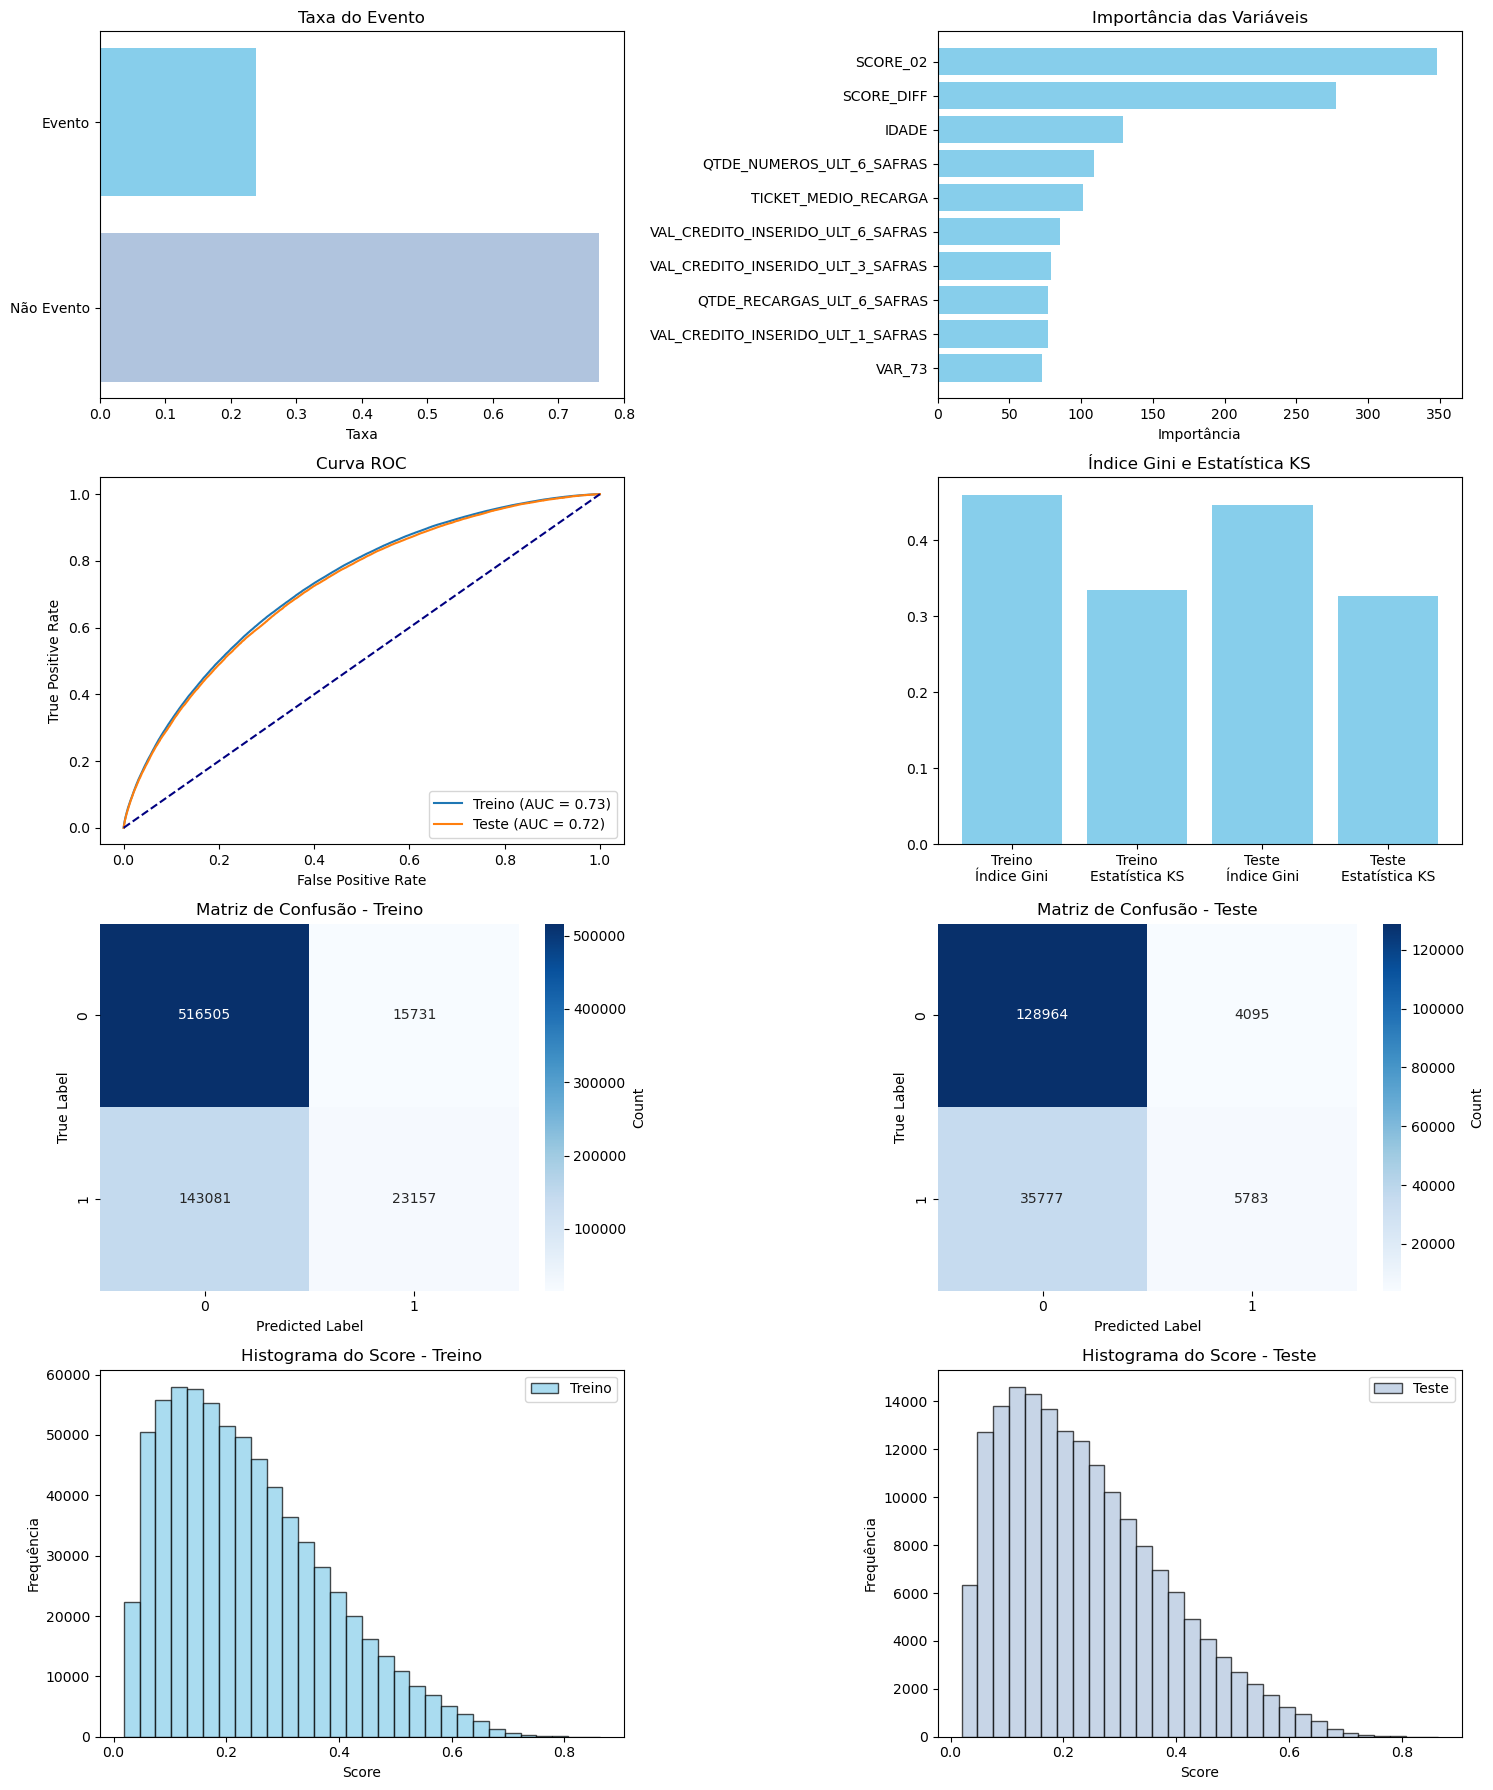

In [38]:
features = X_train_processed.columns
best_algorithm = lgb.LGBMClassifier(random_state=0)
best_algorithm.fit(X_train_processed,y_train)
plot_metrics(best_algorithm, X_train_processed, y_train, X_test_processed, y_test, features)

## 7. Curva Precision Recall

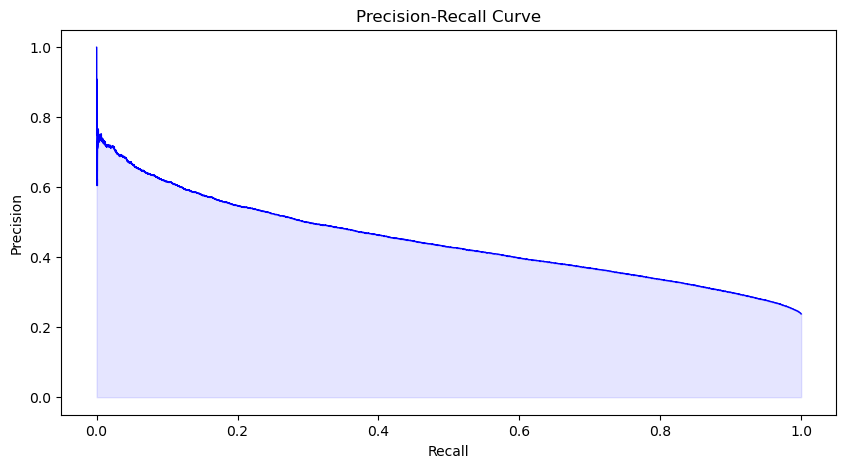

In [12]:
y_probs = best_algorithm.predict_proba(X_test_processed)[:,1]
y_pred = best_algorithm.predict(X_test_processed)

# Precision-Recall curve
precision, recall, thresholds = precision_recall_curve(y_test, y_probs)

# Precision-Recall curve
plt.figure(figsize=(10,5))
plt.plot(recall, precision, color="b", lw=1)
plt.fill_between(recall, precision, alpha=0.1, color="blue")
plt.title('Precision-Recall Curve')
plt.xlabel('Recall')
plt.ylabel('Precision');

### 7.1 Classification Report sem alteração na configuração padrão do Threshold (0.5)

In [13]:
# Avaliação do modelo ajustado
from sklearn.metrics import classification_report

print("Relatório de classificação com novo limiar:")
print(classification_report(y_test, y_pred))

Relatório de classificação com novo limiar:
              precision    recall  f1-score   support

           0       0.78      0.97      0.87    133059
           1       0.59      0.14      0.22     41560

    accuracy                           0.77    174619
   macro avg       0.68      0.55      0.55    174619
weighted avg       0.74      0.77      0.71    174619



### 7.2 Classification Report após alteração no Threshold

In [14]:
from sklearn.metrics import precision_recall_curve
import numpy as np

# Obtenção das probabilidades para a classe positiva
y_probs = best_algorithm.predict_proba(X_test_processed)[:, 1]

# Calcula Precision, Recall e os thresholds correspondentes
precision, recall, thresholds = precision_recall_curve(y_test, y_probs)

# Evitar divisão por zero - filtrando F1-Scores válidos
f1_scores = 2 * (precision * recall) / (precision + recall + 1e-9)  # Pequeno valor para evitar divisão por zero

# Encontra o índice do threshold que maximiza o F1-Score
best_index = np.argmax(f1_scores)
best_threshold = thresholds[best_index]

# Mostra o melhor threshold e o F1-Score correspondente
print(f"Melhor threshold para maximizar Precision e Recall: {best_threshold:.3f}")
print(f"F1-Score correspondente: {f1_scores[best_index]:.3f}")

# Aplica o novo limiar para ajustar as predições
y_pred_adjusted = (y_probs >= best_threshold).astype(int)

# Avaliação do modelo ajustado
from sklearn.metrics import classification_report

print("Relatório de classificação com novo limiar:")
print(classification_report(y_test, y_pred_adjusted))

Melhor threshold para maximizar Precision e Recall: 0.240
F1-Score correspondente: 0.484
Relatório de classificação com novo limiar:
              precision    recall  f1-score   support

           0       0.87      0.64      0.74    133059
           1       0.37      0.68      0.48     41560

    accuracy                           0.65    174619
   macro avg       0.62      0.66      0.61    174619
weighted avg       0.75      0.65      0.68    174619



## 8. Tunagem de hiperparâmetros

In [41]:
import optuna
import lightgbm as lgb
from sklearn.pipeline import Pipeline
from sklearn.metrics import roc_auc_score
from optuna.samplers import TPESampler

def objective(trial):
    param = {
        'n_estimators':      trial.suggest_int('n_estimators', 50, 500),
        'max_depth':         trial.suggest_int('max_depth', 3, 10),
        'learning_rate':     trial.suggest_float('learning_rate', 1e-4, 1e-1, log=True),
        'subsample':         trial.suggest_float('subsample', 0.5, 1.0),
        'colsample_bytree':  trial.suggest_float('colsample_bytree', 0.5, 1.0),
        'reg_alpha':         trial.suggest_float('reg_alpha', 1e-8, 1.0, log=True),
        'reg_lambda':        trial.suggest_float('reg_lambda', 1e-8, 1.0, log=True),
        'min_child_samples': trial.suggest_int('min_child_samples', 5, 100),  # equiv. min_child_weight
        'num_leaves':        trial.suggest_int('num_leaves', 20, 300),        # exclusivo do LGBM
        'random_state': 0,
        'verbosity': -1
    }

    model = lgb.LGBMClassifier(**param)
    pipeline = Pipeline(steps=[('model', model)])
    pipeline.fit(X_train_processed, y_train)

    y_pred_probs = pipeline.predict_proba(X_test_processed)[:, 1]
    auc = roc_auc_score(y_test, y_pred_probs)

    return auc

# Early stopping — igual ao original
class EarlyStoppingCallback:
    def __init__(self, patience: int):
        self.patience = patience
        self.best_score = None
        self.num_no_improvement = 0

    def __call__(self, study: optuna.study.Study, trial: optuna.trial.FrozenTrial):
        current_score = study.best_value
        if self.best_score is None or current_score > self.best_score:
            self.best_score = current_score
            self.num_no_improvement = 0
        else:
            self.num_no_improvement += 1

        if self.num_no_improvement >= self.patience:
            study.stop()

early_stopping = EarlyStoppingCallback(patience=20)

study = optuna.create_study(direction='maximize', sampler=TPESampler(seed=0))
study.optimize(objective, n_trials=20, n_jobs=-1, callbacks=[early_stopping])

print(f"Melhores hiperparâmetros: {study.best_params}")
print(f"Melhor AUC-ROC: {study.best_value:.4f}")

[I 2026-03-10 21:26:49,298] A new study created in memory with name: no-name-4c5a1753-4c71-4686-ba88-72850b4f3b36
[I 2026-03-10 21:28:04,977] Trial 12 finished with value: 0.6998695521039351 and parameters: {'n_estimators': 135, 'max_depth': 3, 'learning_rate': 0.0011628308835771519, 'subsample': 0.8375373565050663, 'colsample_bytree': 0.8592150815201037, 'reg_alpha': 1.2602989266266197e-08, 'reg_lambda': 1.4075278160431867e-05, 'min_child_samples': 65, 'num_leaves': 171}. Best is trial 12 with value: 0.6998695521039351.
[I 2026-03-10 21:29:46,426] Trial 14 finished with value: 0.7197302439181512 and parameters: {'n_estimators': 69, 'max_depth': 5, 'learning_rate': 0.08398104875596295, 'subsample': 0.95818935427822, 'colsample_bytree': 0.9746109788978523, 'reg_alpha': 0.0007677053918647027, 'reg_lambda': 7.689888348655537e-07, 'min_child_samples': 49, 'num_leaves': 113}. Best is trial 14 with value: 0.7197302439181512.
[I 2026-03-10 21:30:26,114] Trial 7 finished with value: 0.70851995

Melhores hiperparâmetros: {'n_estimators': 76, 'max_depth': 6, 'learning_rate': 0.07782220132451474, 'subsample': 0.7501323132849341, 'colsample_bytree': 0.9618923419469735, 'reg_alpha': 0.13662170832577974, 'reg_lambda': 3.514169393426541e-05, 'min_child_samples': 57, 'num_leaves': 111}
Melhor AUC-ROC: 0.7214


In [42]:
best_params = {'n_estimators': 76, 'max_depth': 6, 'learning_rate': 0.07782220132451474, 'subsample': 0.7501323132849341, 'colsample_bytree': 0.9618923419469735, 'reg_alpha': 0.13662170832577974, 'reg_lambda': 3.514169393426541e-05, 'min_child_samples': 57, 'num_leaves': 111}

### 8.1 Treinar algoritmo com a melhor configuração de hiperparâmetros

[LightGBM] [Info] Number of positive: 166238, number of negative: 532236
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0,090609 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 10695
[LightGBM] [Info] Number of data points in the train set: 698474, number of used features: 122
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0,238002 -> initscore=-1,163667
[LightGBM] [Info] Start training from score -1,163667
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, bes

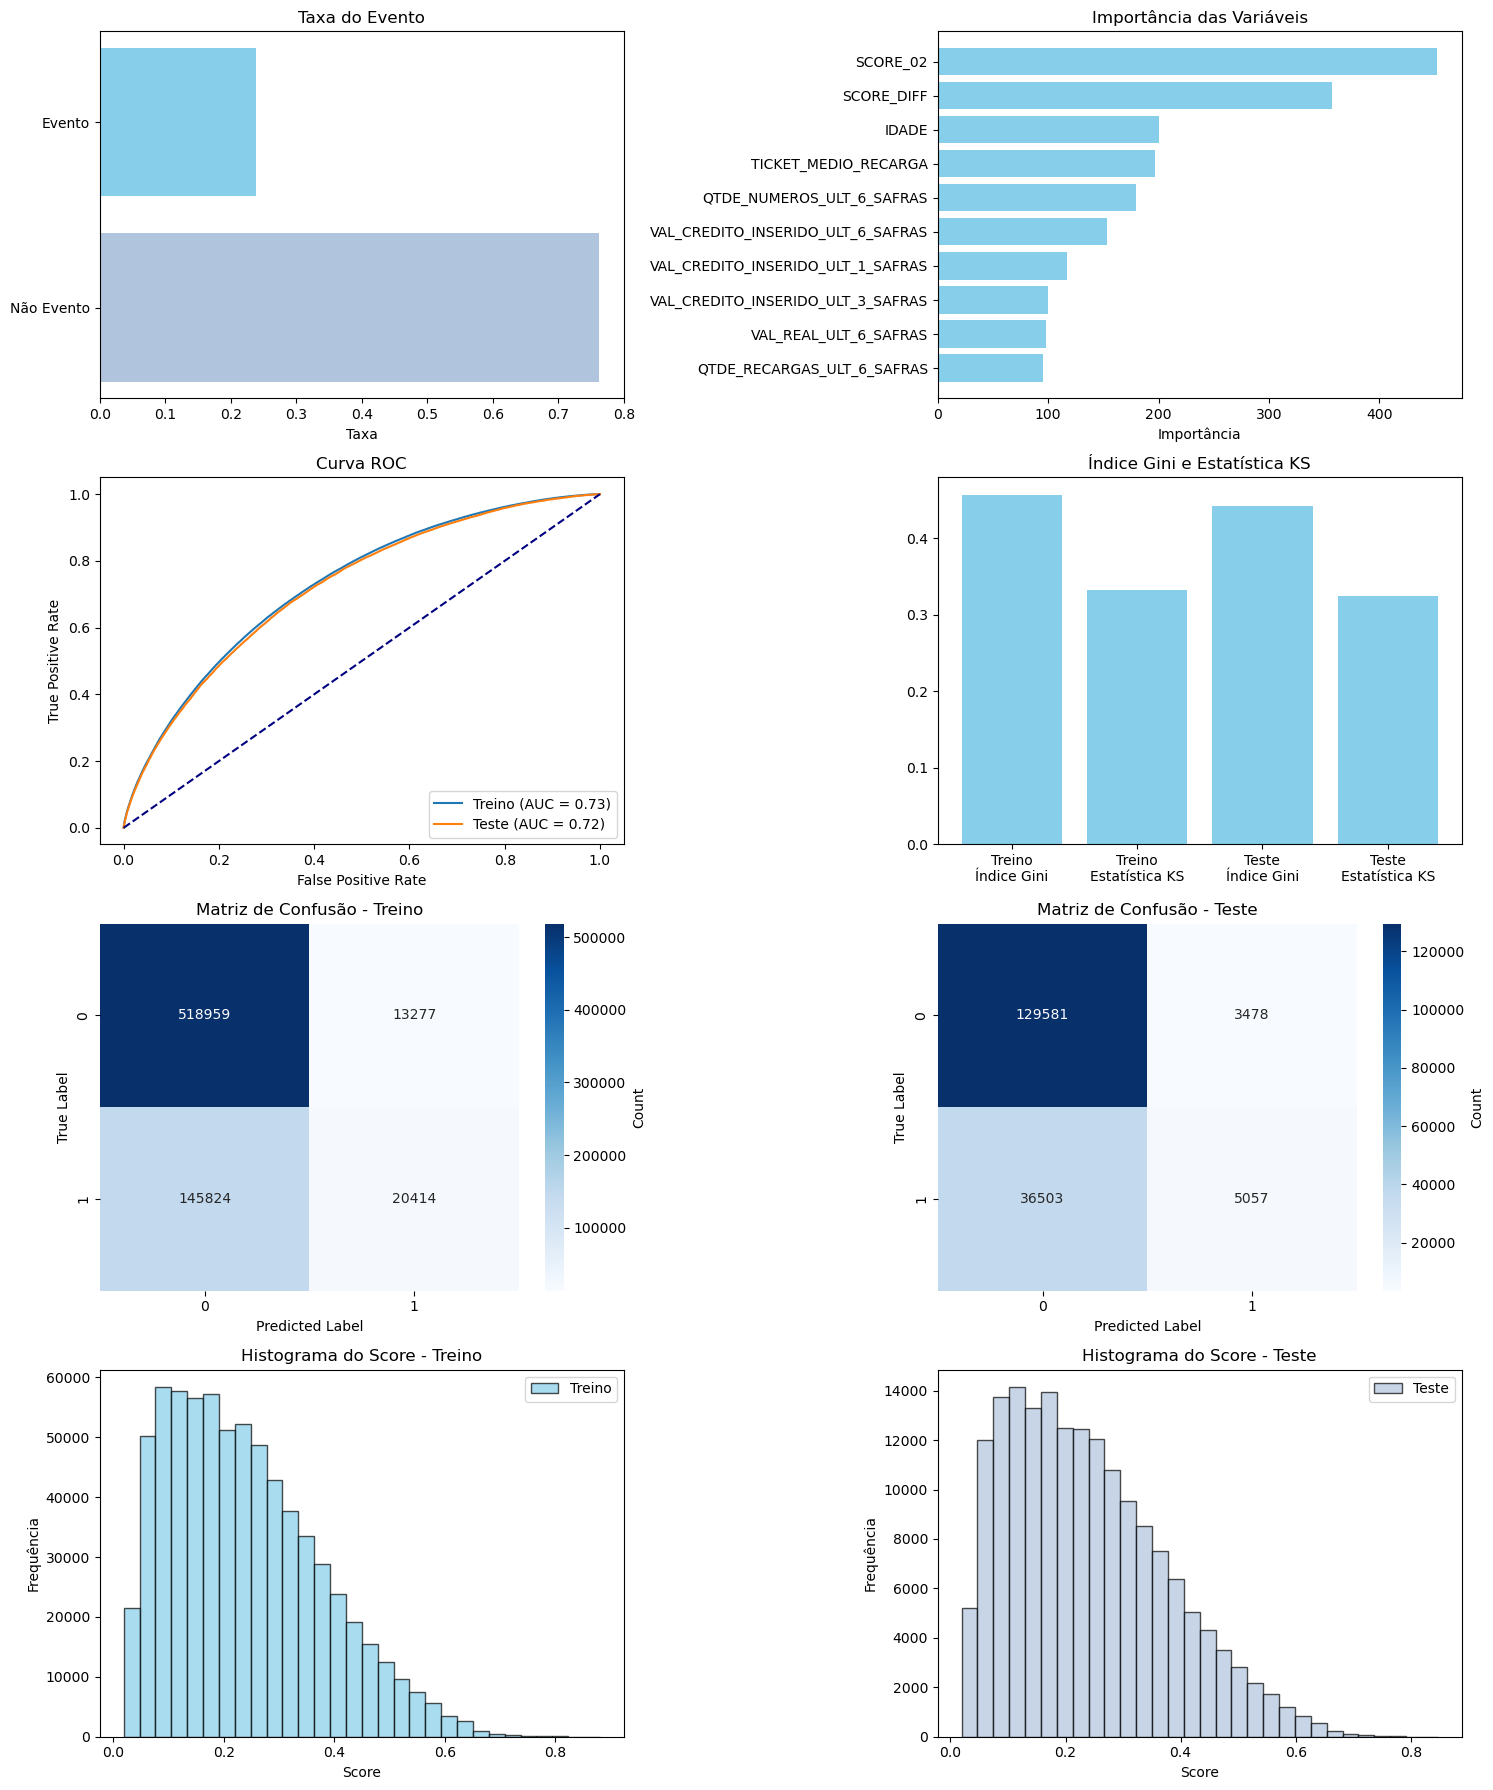

In [43]:
features = X_train_processed.columns
best_algorithm_tuned = lgb.LGBMClassifier(random_state=0,**best_params)
best_algorithm_tuned.fit(X_train_processed,y_train)
plot_metrics(best_algorithm_tuned, X_train_processed, y_train, X_test_processed, y_test, features)


## 9. Análise de variáveis importantes para o modelo

### 9.1 Visualização das 15 variáveis mais importantes

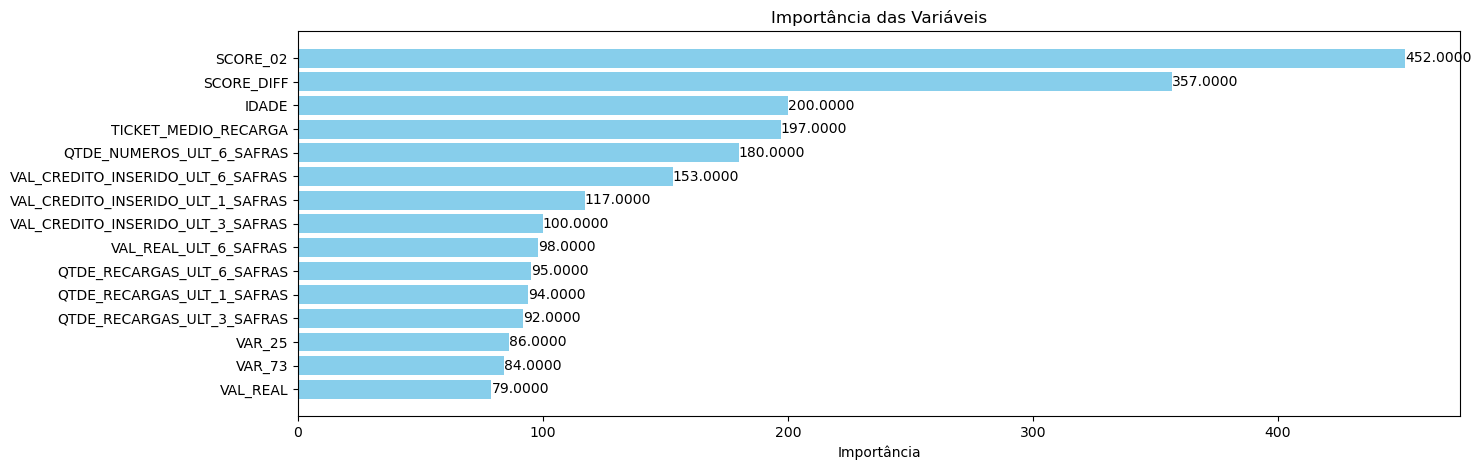

In [44]:
plt.figure(figsize=(15,5))

importances = best_algorithm_tuned.feature_importances_
indices = np.argsort(importances)  # Ordem ascendente
indices = indices[-15:]  # Considerando apenas as 15 mais importantes

plt.barh(features[indices], importances[indices], color='skyblue')
plt.xlabel('Importância')
plt.title('Importância das Variáveis')

# Adicionar os valores de importância ao lado de cada barra
for i, v in enumerate(importances[indices]):
    plt.text(v + 0.0005, i, f'{v:.4f}', va='center')  # Ajuste o valor necessário para espaçamento

plt.show()

### 9.2 Checar quantidade de variáveis que entraram no modelo

In [45]:
qtd_vars_modelo = (importances > 0).sum()
print(f'Quantidade de variáveis que entraram no modelo: {qtd_vars_modelo}')

Quantidade de variáveis que entraram no modelo: 110


### 9.4 Checar desempenho do modelo

In [46]:
metricas = calculate_metrics('LightGBM',best_algorithm_tuned, X_train_processed, y_train, X_test_processed, y_test)
display(metricas)

,Algoritmo,Conjunto,Acuracia,Precisao,Recall,AUC_ROC,GINI,KS
0,LightGBM,Treino,0.772216,0.605918,0.122800,0.728409,0.456818,0.332098
1,LightGBM,Teste,0.771039,0.592501,0.121679,0.721434,0.442867,0.324851


### 9.7.1 Maximizando ROC-AUC

In [41]:
import optuna
from xgboost import XGBClassifier
from sklearn.pipeline import Pipeline
from sklearn.metrics import roc_auc_score
from optuna.samplers import TPESampler

# Definir o pipeline
cat_attributes_vars_selected_v1 = X_train[vars_selected_v1].select_dtypes(include='object')
num_attributes_vars_selected_v1 = X_train[vars_selected_v1].select_dtypes(exclude='object')

# Define categorical pipeline
cat_pipe_vars_selected_v1 = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('encoder', TargetEncoder())
])

# Define numerical pipeline
num_pipe_vars_selected_v1 = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler',StandardScaler())
])

# Combine categorical and numerical pipelines
preprocessor_vars_selected_v1 = ColumnTransformer([
    ('cat', cat_pipe_vars_selected_v1, cat_attributes_vars_selected_v1.columns),
    ('num', num_pipe_vars_selected_v1, num_attributes_vars_selected_v1.columns)
])
preprocessor_vars_selected_v1 = Pipeline(steps=[("preprocessor", preprocessor_vars_selected_v1)])



# Inicializar os hiperparâmetros conhecidos
init_params = {
    'n_estimators': 497,
    'max_depth': 9,
    'learning_rate': 0.05064131970082176,
    'subsample': 0.9017014890228775,
    'colsample_bytree': 0.7349176134551406,
    'gamma': 3.357582904408152e-05,
    'reg_alpha': 0.9974231664030752,
    'reg_lambda': 3.4312469095456225e-05,
    'min_child_weight': 5
}

# Função objetivo para otimização do XGBoost
def objective(trial):
    # Sugerir hiperparâmetros para o XGBoost
    param = {
        'n_estimators': trial.suggest_int('n_estimators', 50, 500) if trial.number > 0 else init_params['n_estimators'],
        'max_depth': trial.suggest_int('max_depth', 3, 10) if trial.number > 0 else init_params['max_depth'],
        'learning_rate': trial.suggest_float('learning_rate', 1e-4, 1e-1, log=True) if trial.number > 0 else init_params['learning_rate'],
        'subsample': trial.suggest_float('subsample', 0.5, 1.0) if trial.number > 0 else init_params['subsample'],
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.5, 1.0) if trial.number > 0 else init_params['colsample_bytree'],
        'gamma': trial.suggest_float('gamma', 1e-8, 1.0, log=True) if trial.number > 0 else init_params['gamma'],
        'reg_alpha': trial.suggest_float('reg_alpha', 1e-8, 1.0, log=True) if trial.number > 0 else init_params['reg_alpha'],
        'reg_lambda': trial.suggest_float('reg_lambda', 1e-8, 1.0, log=True) if trial.number > 0 else init_params['reg_lambda'],
        'min_child_weight': trial.suggest_int('min_child_weight', 1, 10) if trial.number > 0 else init_params['min_child_weight'],
        'random_state': 0,
        'eval_metric': 'logloss'
    }

    # Definir o modelo XGBoost com os hiperparâmetros sugeridos
    model = XGBClassifier(**param)

    # Pipeline com preprocessador e modelo
    pipeline_vars_selected_v1 = Pipeline(steps=[('preprocessor', preprocessor_vars_selected_v1),
                               ('model', model)])

    # Treinar o pipeline
    pipeline_vars_selected_v1.fit(X_train[vars_selected_v1], y_train)

    # Prever as probabilidades no conjunto de validação
    y_pred_probs = pipeline_vars_selected_v1.predict_proba(X_test[vars_selected_v1])[:, 1]

    # Calcular AUC-ROC
    auc = roc_auc_score(y_test, y_pred_probs)

    return auc

# Classe para parada antecipada se não houver melhora após 5 iterações
class EarlyStoppingCallback:
    def __init__(self, patience: int):
        self.patience = patience
        self.best_score = None
        self.num_no_improvement = 0

    def __call__(self, study: optuna.study.Study, trial: optuna.trial.FrozenTrial):
        current_score = study.best_value
        if self.best_score is None or current_score > self.best_score:
            self.best_score = current_score
            self.num_no_improvement = 0
        else:
            self.num_no_improvement += 1

        if self.num_no_improvement >= self.patience:
            study.stop()

# Configurar o Early Stopping Callback
early_stopping = EarlyStoppingCallback(patience=25)

# Criar o estudo com a seed para reprodutibilidade e ponto de partida nos hiperparâmetros conhecidos
study = optuna.create_study(direction='maximize', sampler=TPESampler(seed=0))
study.optimize(objective, n_trials=20, n_jobs=-1, callbacks=[early_stopping])

# Melhor conjunto de hiperparâmetros encontrado
print(f"Melhores hiperparâmetros: {study.best_params}")
print(f"Melhor AUC-ROC: {study.best_value:.4f}")

[I 2026-03-10 18:20:42,301] A new study created in memory with name: no-name-655a55fb-0a46-4d01-a796-3716a01339cf


: 

: 

### 9.7.2 Maximizando PR-AUC

In [ ]:
import optuna
from xgboost import XGBClassifier
from sklearn.pipeline import Pipeline
from sklearn.metrics import roc_auc_score
from optuna.samplers import TPESampler

# Definir o pipeline
cat_attributes_vars_selected_v1 = X_train[vars_selected_v1].select_dtypes(include='object')
num_attributes_vars_selected_v1 = X_train[vars_selected_v1].select_dtypes(exclude='object')

# Define categorical pipeline
cat_pipe_vars_selected_v1 = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('encoder', TargetEncoder())
])

# Define numerical pipeline
num_pipe_vars_selected_v1 = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler',StandardScaler())
])

# Combine categorical and numerical pipelines
preprocessor_vars_selected_v1 = ColumnTransformer([
    ('cat', cat_pipe_vars_selected_v1, cat_attributes_vars_selected_v1.columns),
    ('num', num_pipe_vars_selected_v1, num_attributes_vars_selected_v1.columns)
])
preprocessor_vars_selected_v1 = Pipeline(steps=[("preprocessor", preprocessor_vars_selected_v1)])



# Inicializar os hiperparâmetros conhecidos
init_params = {
    'n_estimators': 303,
    'max_depth': 7,
    'learning_rate':  0.020007929802140556,
    'subsample': 0.7561981064601235,
    'colsample_bytree': 0.8939638718194769,
    'gamma': 0.08942843075196766,
    'reg_alpha': 1.2811571869424657e-08,
    'reg_lambda': 4.815855958253978e-07,
    'min_child_weight': 5
}

# Função objetivo para otimização do XGBoost
def objective(trial):
    # Sugerir hiperparâmetros para o XGBoost
    param = {
        'n_estimators': trial.suggest_int('n_estimators', 50, 500) if trial.number > 0 else init_params['n_estimators'],
        'max_depth': trial.suggest_int('max_depth', 3, 10) if trial.number > 0 else init_params['max_depth'],
        'learning_rate': trial.suggest_float('learning_rate', 1e-4, 1e-1, log=True) if trial.number > 0 else init_params['learning_rate'],
        'subsample': trial.suggest_float('subsample', 0.5, 1.0) if trial.number > 0 else init_params['subsample'],
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.5, 1.0) if trial.number > 0 else init_params['colsample_bytree'],
        'gamma': trial.suggest_float('gamma', 1e-8, 1.0, log=True) if trial.number > 0 else init_params['gamma'],
        'reg_alpha': trial.suggest_float('reg_alpha', 1e-8, 1.0, log=True) if trial.number > 0 else init_params['reg_alpha'],
        'reg_lambda': trial.suggest_float('reg_lambda', 1e-8, 1.0, log=True) if trial.number > 0 else init_params['reg_lambda'],
        'min_child_weight': trial.suggest_int('min_child_weight', 1, 10) if trial.number > 0 else init_params['min_child_weight'],
        'random_state': 0,
        'eval_metric': 'logloss'
    }

    # Definir o modelo XGBoost com os hiperparâmetros sugeridos
    model = XGBClassifier(**param)

    # Pipeline com preprocessador e modelo
    pipeline_vars_selected_v1 = Pipeline(steps=[('preprocessor', preprocessor_vars_selected_v1),
                               ('model', model)])

    # Treinar o pipeline
    pipeline_vars_selected_v1.fit(X_train[vars_selected_v1], y_train)

    # Prever as probabilidades no conjunto de validação
    y_pred_probs = pipeline_vars_selected_v1.predict_proba(X_test[vars_selected_v1])[:, 1]

    # Calcular average precision (AUC-PR)
    avg_precision = average_precision_score(y_test, y_pred_probs)

    return avg_precision

# Classe para parada antecipada se não houver melhora após 5 iterações
class EarlyStoppingCallback:
    def __init__(self, patience: int):
        self.patience = patience
        self.best_score = None
        self.num_no_improvement = 0

    def __call__(self, study: optuna.study.Study, trial: optuna.trial.FrozenTrial):
        current_score = study.best_value
        if self.best_score is None or current_score > self.best_score:
            self.best_score = current_score
            self.num_no_improvement = 0
        else:
            self.num_no_improvement += 1

        if self.num_no_improvement >= self.patience:
            study.stop()

# Configurar o Early Stopping Callback
early_stopping = EarlyStoppingCallback(patience=25)

# Criar o estudo com a seed para reprodutibilidade e ponto de partida nos hiperparâmetros conhecidos
study = optuna.create_study(direction='maximize', sampler=TPESampler(seed=0))
study.optimize(objective, n_trials=20, n_jobs=-1, callbacks=[early_stopping])

# Melhor conjunto de hiperparâmetros encontrado
print(f"Melhores hiperparâmetros: {study.best_params}")
print(f"Melhor AUC-PR: {study.best_value:.4f}")

Treinar algoritmo com melhor configuração de hiperparâmetros

In [ ]:
best_params = {'n_estimators': 497, 'max_depth': 9, 'learning_rate': 0.05064131970082176, 'subsample': 0.9017014890228775, 'colsample_bytree': 0.7349176134551406, 'gamma': 3.357582904408152e-05, 'reg_alpha': 0.9974231664030752, 'reg_lambda': 3.4312469095456225e-05, 'min_child_weight': 5}

features = X_train_processed.columns
# modelo_simplificado_v1_tuned = best_algorithm_tuned = XGBClassifier(random_state=0,**study.best_params)
modelo_simplificado_v1_tuned = best_algorithm_tuned = XGBClassifier(random_state=0,**best_params)
modelo_simplificado_v1_tuned.fit(X_train_processed[vars_selected_v1],y_train)
plot_metrics(best_algorithm_tuned, X_train_processed[vars_selected_v1], y_train, X_test_processed[vars_selected_v1], y_test, features)

y_simplificado_probs_tuned = modelo_simplificado_v1_tuned.predict_proba(X_test_processed[vars_selected_v1])[:,1]

### 9.8 Ajuste no threshold

Como não houve mudança no modelo após tunar hiperparâmetros, não precisaremos reajustar o threshold. Entretanto, se houvesse alguma mudança durante a etapa de tuning, seria necessário reajustar o threshold para avaliar o desempenho (Precision e Recall).

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import precision_recall_curve

# Supondo que você já tenha os arrays: y_true e y_pred_proba
precision_simplificado_tuned, recall_simplificado_tuned, thresholds_tuned = precision_recall_curve(y_test, y_simplificado_probs_tuned)

# Calcular o F1-score para cada ponto
f1_scores = 2 * (precision_simplificado_tuned * recall_simplificado_tuned) / (precision_simplificado_tuned + recall_simplificado_tuned + 1e-32)

# Encontrar o índice que maximiza o F1-score
best_f1_index = np.argmax(f1_scores)
best_threshold = thresholds_tuned[best_f1_index - 1]  # -1 para alinhar com o tamanho do array de thresholds
best_f1_score = f1_scores[best_f1_index]

# Encontrar o índice onde o recall é aproximadamente 0.0662
recall_target = 0.0662
recall_index = (np.abs(recall_simplificado_tuned - recall_target)).argmin()

# Plot Precision-Recall Curve
plt.figure(figsize=(10, 5))
plt.plot(recall_simplificado_tuned, precision_simplificado_tuned, color='b', lw=0.5, label='Precision-Recall curve')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve')

# Marcar o ponto onde recall é 0.0662
plt.scatter(recall_simplificado_tuned[recall_index], precision_simplificado_tuned[recall_index], color='green', label=f'Recall = {recall_target}', zorder=2)

plt.legend()
plt.show()

print('Priorizando a configuração de melhor F1-score:')
print(f'Melhor F1-score: {best_f1_score:.4f}')
print(f'Threshold correspondente ao F1-score máximo: {best_threshold}')
print(f'Precision: {precision_simplificado_tuned[best_f1_index]}')
print(f'Recall: {recall_simplificado_tuned[best_f1_index]}')

f1_score = 2 * (precision_simplificado_tuned[recall_index] * recall_target) / (precision_simplificado_tuned[recall_index] + recall_target + 1e-32)
print(70*'-')
print('Priorizando outra configuração com menor recall entretanto um maior precision:')
print(f'Precision: {precision_simplificado_tuned[recall_index]:.4f}')
print(f'Recall: {recall_simplificado_tuned[recall_index]:.4f}')
print(f'Threshold: {thresholds_tuned[recall_index-1]:.16f}')
print(f'F1-score: {f1_score}')

### 9.9 Avaliação dos resultados por mês de referência

In [ ]:
from sklearn.metrics import roc_auc_score

# Lista para armazenar os resultados
results = []

base_teste_vars_pred = X_test_processed[vars_selected_v1].copy()
base_teste_vars_pred.loc[:,'TX_FRAUDE'] = y_test.reset_index(drop=True)
base_teste_vars_pred.loc[:,'SCORE_FRAUDE'] = y_simplificado_probs_tuned
base_teste_vars_pred.loc[:,'PRED_FRAUDE'] = (y_simplificado_probs_tuned >= best_threshold).astype(int)
base_teste_vars_pred.loc[:,'MONTH_REFERENCE'] = X_test['MONTH_REFERENCE'].reset_index(drop=True)

base_scores = X_test.copy()
base_scores.loc[:,'SCORE_FRAUDE_XGBOOST'] = y_simplificado_probs_tuned
base_scores.loc[:,'PRED_FRAUDE_XGBOOST'] = (y_simplificado_probs_tuned >= best_threshold).astype(int)

# Calcular precision, recall, roc_auc e gini por safra
for safra in base_teste_vars_pred['MONTH_REFERENCE'].unique():
    subset = base_teste_vars_pred[base_teste_vars_pred['MONTH_REFERENCE'] == safra]

    # Precision e Recall
    precision = precision_score(subset['TX_FRAUDE'], subset['PRED_FRAUDE'], zero_division=0)
    recall = recall_score(subset['TX_FRAUDE'], subset['PRED_FRAUDE'], zero_division=0)

    # ROC AUC
    if subset['TX_FRAUDE'].nunique() > 1:  # Garantir que existem ambas as classes (0 e 1)
        roc_auc = roc_auc_score(subset['TX_FRAUDE'], subset['SCORE_FRAUDE'])
    else:
        roc_auc = 0.5  # Valor neutro quando só há uma classe

    # GINI
    gini = 2 * roc_auc - 1

    # Armazenar os resultados
    results.append({
        'MONTH_REFERENCE': safra,
        'precision': precision,
        'recall': recall,
        'roc_auc': roc_auc,
        'gini': gini
    })

# Criar um DataFrame com os resultados
results_df = pd.DataFrame(results)
results_df = results_df.sort_values(by='MONTH_REFERENCE')

# Converter a coluna 'MONTH_REFERENCE' para int
results_df['MONTH_REFERENCE'] = results_df['MONTH_REFERENCE'].astype(int)

# Plotar gráficos de linhas
plt.figure(figsize=(15, 6))

# Precision e Recall
plt.plot(results_df['MONTH_REFERENCE'], results_df['precision'], marker='o', label='Precision', color='blue')
plt.plot(results_df['MONTH_REFERENCE'], results_df['recall'], marker='o', label='Recall', color='orange')

# ROC AUC e GINI
plt.plot(results_df['MONTH_REFERENCE'], results_df['roc_auc'], marker='o', label='ROC AUC', color='green')
plt.plot(results_df['MONTH_REFERENCE'], results_df['gini'], marker='o', label='GINI', color='red')

plt.title('Precision, Recall, ROC AUC, and GINI by MONTH_REFERENCE')
plt.xlabel('MONTH_REFERENCE')
plt.ylabel('Score')
plt.xticks(results_df['MONTH_REFERENCE'])  # Adicionar ticks no eixo x
plt.grid()
plt.legend()
plt.show()

In [ ]:
results_df

In [ ]:
# Taxa média de fraude na base
avg_fraud = base_teste_vars_pred.TX_FRAUDE.mean()

ref_fraud = base_teste_vars_pred.groupby('MONTH_REFERENCE')['TX_FRAUDE'].mean().reset_index().rename(columns={'TX_FRAUDE':'AVG_FRAUD_PER_MONTH_REFERENCE'})

print(f'Taxa média de fraude na base: {100*avg_fraud:.2f}%')

ref_fraud

In [ ]:
# Exportar o DataFrame para um arquivo Excel (.xlsx)
base_teste_vars_pred.to_excel('base_teste_vars_pred.xlsx', index=False)

from google.colab import files

# Baixar o arquivo Excel gerado
files.download('base_teste_vars_pred.xlsx')

## 9.10 Salvar base com scores dados pelo Random Forest

In [ ]:
# Testar outros modelos
algoritmo = RandomForestClassifier(random_state=0)

# Treino do modelo
algoritmo.fit(X_train_processed,y_train)

# Realizar predições
base_scores['SCORE_FRAUDE_RANDOM_FOREST'] = algoritmo.predict_proba(X_test_processed)[:,1]
base_scores['PRED_FRAUDE_RANDOM_FOREST'] = algoritmo.predict(X_test_processed)

# Marcar o target
base_scores['TX_FRAUDE'] = y_test.copy()

# Exportar o DataFrame para um arquivo Excel (.xlsx)
base_scores.to_excel('base_scores.xlsx', index=False)

from google.colab import files

# Baixar o arquivo Excel gerado
files.download('base_scores.xlsx')